# Your Task:
## Exploratory Data Analysis
- Use pandas to load the dataset and examine the first few rows.
- Check and handle the missing values.
- Drop any unnecessary column
- Create a Countplot to display diagnosis from magma

## Data Preprocessing, Building Models and Evaluation :
- counts of unique rows in the ‘diagnosis’ column
- map categorical values to numerical values
- Splitting the data into train and test
- Implement logistic regression and print the accuracy.
- Implement K Nearest Neighbours and print the accuracy.
- Implement Random Forests and print the accuracy.
- Implement Support Vector Machines (SVM) and print the accuracy.
- Which is the best model ?

### 1. Load the dataset and examine the first few row

In [116]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/breast-cancer-wisconsin-data",
  file_path,
)

print("First 5 records: \n", df.head())

/var/folders/8v/70qw8r3179s_q7rzt2fpxw4r0000gn/T/ipykernel_14506/1827020634.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records: 
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  are

### 2. Check and handle the missing values.

In [117]:
df.drop(columns=['Unnamed: 32', 'id'], inplace=True)
print(f'We have {df.shape[0]} patients and {df.shape[1]} columns')
print(f'{df.info()}')
print(f'total missing values per column: {df.isnull().sum()}')
print('No missing data to handle.')

We have 569 patients and 31 columns
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  a

### 3. Create a Countplot to display diagnosis from magma

Number of Benign:  357
Number of Malignant:  212
In diagnosis column, we have 2 unique value: M, B


/var/folders/8v/70qw8r3179s_q7rzt2fpxw4r0000gn/T/ipykernel_14506/2772117123.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(df, x='diagnosis', palette='magma')


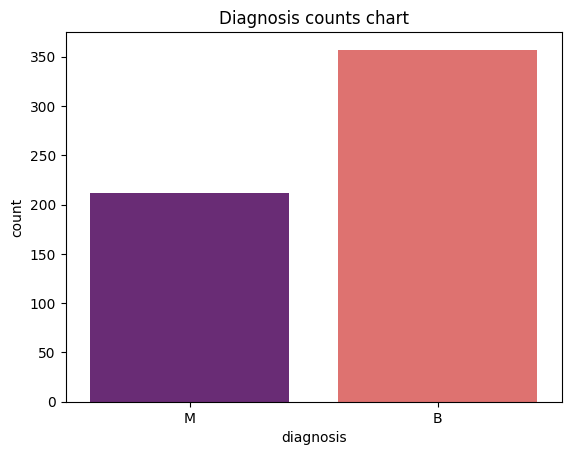

In [118]:
y = df['diagnosis']
diagnosis_unique = y.unique()
B, M = y.value_counts()
print('Number of Benign: ', B)
print('Number of Malignant: ', M)

print(f'In diagnosis column, we have {len(diagnosis_unique)} unique value: {', '.join(diagnosis_unique)}')
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(df, x='diagnosis', palette='magma')
plt.title('Diagnosis counts chart')
plt.show()



### 4. Map categorical values to numerical values


In [119]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df.head()


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 5. Splitting the data into train and test, Feature scaling for numerical values 

In [120]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

y = df['diagnosis']
X = df.drop(columns='diagnosis')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler() # good for 'assumed' normal distributed data with outliers
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




### 6.1 Implement logistic regression , train and test and evaluation

Accuracy: 97.37%
precision: 97.62%
recall: 95.35%
f1 score: 96.47%
classification report:
              precision    recall  f1-score   support

           B       0.97      0.99      0.98        71
           M       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



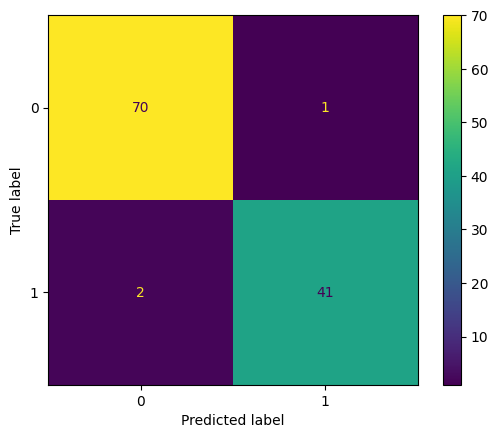

In [132]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

logisticReg = LogisticRegression()
logisticReg.fit(X_train_scaled, y_train)
y_pred_logreg = logisticReg.predict(X_test_scaled)

# Main Metrics
print(f'Accuracy: {accuracy_score(y_test, y_pred_logreg)*100:.2f}%')
print(f'precision: {precision_score(y_test, y_pred_logreg)*100:.2f}%')
print(f'recall: {recall_score(y_test, y_pred_logreg)*100:.2f}%')
print(f'f1 score: {f1_score(y_test, y_pred_logreg)*100:.2f}%')
print('classification report:')
print(classification_report(y_test, y_pred_logreg, target_names=['B', 'M']))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_logreg)
ConfusionMatrixDisplay(cm).plot()


### 6.2 Implement K Nearest Neighbors and print the accuracy.


Accuracy: 96.49%
classification report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



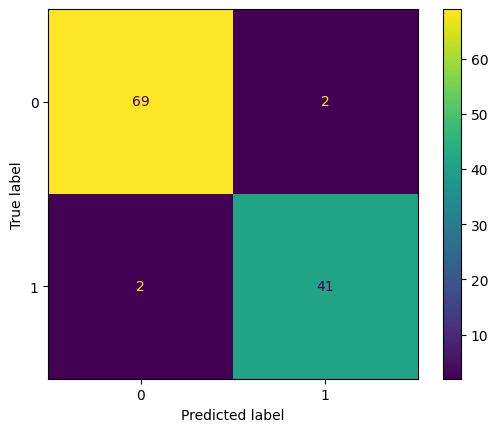

In [154]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# main metrics
print(f'Accuracy: {accuracy_score(y_test, y_pred_knn)*100:.2f}%')
print('classification report:')
print(classification_report(y_test, y_pred_knn))

# confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
# plt.figure(figsize=(6, 4))
# sns.heatmap(cm_knn, xticklabels=['B', 'M'], yticklabels=['B', 'M'], cmap='Blues', annot=True, fmt='d')
# plt.show()
ConfusionMatrixDisplay(cm_knn).plot()


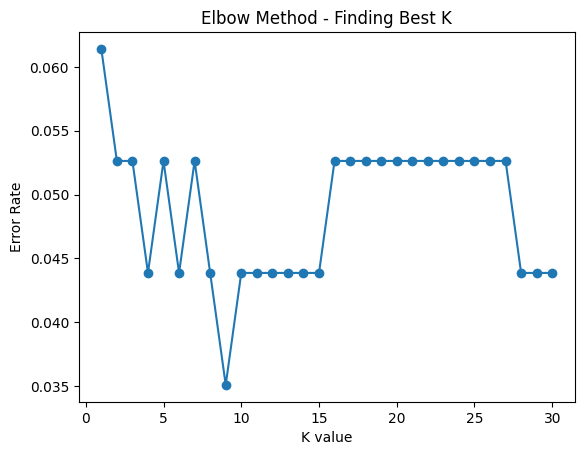

Best K value is 9 according to plot


In [155]:
# Elbow method: finding the best k for K neighbors
error_rates = []

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn_itra = knn.predict(X_test_scaled)
    error_rates.append(1 - accuracy_score(y_test, y_pred_knn_itra))
    
# plot
plt.plot(range(1, 31), error_rates, marker='o')
plt.xlabel('K value')
plt.ylabel('Error Rate')
plt.title('Elbow Method - Finding Best K')
plt.show()
print('Best K value is 9 according to plot')

### 6.3  Implement Random Forests and print the accuracy.

In [150]:
from sklearn.ensemble import RandomForestClassifier

# Random forest doesn't need scaled data
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest (100 trees)')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%')
print('vs')
print(f'Logistics Regression: {accuracy_score(y_test, y_pred_logreg)*100:.2f}%')
print(f'KNN: {accuracy_score(y_test, y_pred_knn)*100:.2f}%')



Random Forest (100 trees)
Accuracy: 96.49%
vs
Logistics Regression: 97.37%
KNN: 95.61%


### 6.4 Implement Support Vector Machines (SVM) and print the accuracy.

In [151]:
from sklearn.svm import SVC

svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

print("Support Vector Machine (RBF kernel)")
print(f'Accuracy: {accuracy_score(y_test, y_pred_svm)*100:.2f}%')

Support Vector Machine (RBF kernel)
Accuracy: 98.25%


In [152]:
# compare different kernels
kernels = ['linear', 'rbf', 'poly']
for k in kernels:
    svm_temp = SVC(kernel=k, random_state=42)
    svm_temp.fit(X_train_scaled, y_train)
    y_pred_svm_temp = svm_temp.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_svm_temp)
    print(f'kernel: {k:8s}: {acc*100:.2f}%')

kernel: linear  : 95.61%
kernel: rbf     : 98.25%
kernel: poly    : 86.84%


### 7. Which one is the best model?

according to accuracy, SVM seems like the best model
SVM has the highest accuracy (98.25%) and is the best model here.
However, for cancer diagnosis, recall is the most important metric
since missing a malignant case is dangerous